# Imports & Installs

In [ ]:
# Upgrade HuggingFace + Transformers first (to avoid being downgraded later)
!pip install -U transformers sentence-transformers huggingface-hub

# Install BERTopic without triggering a Torch reinstall
!pip install -U bertopic[gensim]>=0.17.0 --no-deps

# Add remaining utilities
!pip install -U textblob openai umap-learn tqdm scikit-learn matplotlib plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.4/515.4 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu

In [13]:
# Google Colab
from google.colab import drive
import gc

# Basic Python
import pandas as pd
import numpy as np
import re
from ast import literal_eval
from collections import defaultdict, Counter
import itertools
import time
from tqdm import tqdm
tqdm.pandas()

# ML
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity

# NLP
import torch
from textblob import TextBlob
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

# Instruct LLM
from openai import OpenAI
import openai

# Viz
import umap.umap_ as umap
import matplotlib.pyplot as plt
import plotly.express as px
from ipywidgets import interact, Dropdown

# load the Dataset

In [ ]:
drive.mount('/content/drive')

# File ID extracted from the URL
DATA_PATH = "/content/drive/MyDrive/classified_comment_stance.csv"
OUTPUT_PATH = "/content/drive/MyDrive/classified_comment_stance_with_features.csv"

# Load dataset as pd.DataFrame
tweets_df = pd.read_csv(DATA_PATH)
tweets_df = tweets_df[tweets_df["predicted_label"].isin(["Pro-Israel", "Pro-Palestine"])] # I don't need class `Undefined` for analysis
columns_order = ['comment_id', 'self_text', 'created_time', 'author_name', 'ups', 'downs', 'score',
       'post_id', 'subreddit', 'post_self_text', 'post_title', 'post_created_time', 'post_score',
       'user_mentions', 'media_links', 'predicted_label']
tweets_df = tweets_df[columns_order]
print("Dataset Size", len(tweets_df))
print("Dataset Columns", tweets_df.columns)
tweets_df.head()

Mounted at /content/drive
Dataset Size 847722
Dataset Columns Index(['comment_id', 'self_text', 'created_time', 'author_name', 'ups',
       'downs', 'score', 'post_id', 'subreddit', 'post_self_text',
       'post_title', 'post_created_time', 'post_score', 'user_mentions',
       'media_links', 'predicted_label', 'toxic', 'severe_toxic', 'obscene',
       'threat', 'insult', 'identity_hate', 'sentiment_score', 'factual_score',
       'emotional_score', 'emotionality_score'],
      dtype='object')


,comment_id,self_text,created_time,author_name,ups,downs,score,post_id,subreddit,post_self_text,...,toxic,severe_toxic,obscene,threat,insult,identity_hate,sentiment_score,factual_score,emotional_score,emotionality_score
0,mwgten5,We're already there. The killing just isn't en...,2025-06-07 10:08:13,HailLugalKiEn,1,0,1,1l5cxvw,PublicFreakout,NaN,...,0.861703,0.008666,0.031515,0.050460,0.020646,0.027010,-0.558051,0.541578,0.000000,0.132246
1,mwgte3r,Thats not the definition of tokenism. That is ...,2025-06-07 10:08:03,Agreeable_Recipe3075,1,0,1,1l53z09,IsraelPalestine,Ive been thinking a lot about what it means to...,...,0.675261,0.041063,0.074240,0.045790,0.076220,0.087427,-0.172264,0.114202,0.450013,0.098328
2,mwgtbzy,I dont know if youre being serious but Im goin...,2025-06-07 10:07:29,EastInspection3,1,0,1,1l58igy,IsraelPalestine,I am an AfroCaribbean American who has lived a...,...,0.855340,0.009571,0.032075,0.018114,0.041178,0.043722,-0.836618,0.305234,0.223883,0.972248
3,mwgtbo2,"""most""? all i'm hearing from this crowd is the...",2025-06-07 10:07:23,maybe_lucifer,1,0,1,1l5fpuv,worldnews,NaN,...,0.738017,0.005339,0.011000,0.029338,0.015336,0.200970,-0.828669,0.274337,0.295208,0.987587
4,mwgtb1r,So what are we doing about Hamas then? I see p...,2025-06-07 10:07:13,Spare_Original_4334,1,0,1,1l5fpuv,worldnews,NaN,...,0.512961,0.075688,0.104565,0.082592,0.111765,0.112429,-0.843869,0.402772,0.136351,0.902945


In [ ]:
def summarize_dataframe(df):
    summary = {}

    for column in df.columns:
        col_data = df[column]

        # Detect list-valued column
        is_list_col = col_data.dropna().apply(lambda x: isinstance(x, list)).all()

        if is_list_col:
            # Consider empty lists as nulls
            n_nulls = col_data.apply(lambda x: not x if isinstance(x, list) else True).sum()

            # Flatten non-empty lists
            flattened = col_data.dropna().explode().dropna()
            summary[column] = {
                'type': 'list[str]',
                'n_unique_items': flattened.nunique(),
                'n_nulls': n_nulls,
                'most_common_items': flattened.value_counts().head(5).to_dict()
            }

        elif pd.api.types.is_numeric_dtype(col_data):
            summary[column] = {
                'type': 'numeric',
                'min': col_data.min(),
                'max': col_data.max(),
                'mean': col_data.mean(),
                'n_nulls': col_data.isnull().sum(),
                'n_unique': col_data.nunique()
            }

        elif pd.api.types.is_bool_dtype(col_data):
            summary[column] = {
                'type': 'binary',
                'min': col_data.min(),
                'max': col_data.max(),
                'mean': col_data.mean(),
                'n_nulls': col_data.isnull().sum(),
                'n_unique': col_data.nunique()
            }

        elif pd.api.types.is_object_dtype(col_data):
            try:
                summary[column] = {
                    'type': 'categorical',
                    'n_unique': col_data.nunique(),
                    'n_nulls': col_data.isnull().sum(),
                    'most_common': col_data.value_counts().head(5).to_dict()
                }
            except TypeError:
                summary[column] = {
                    'type': 'object (unhashable)',
                    'note': 'Contains unhashable types like lists or dicts',
                    'n_nulls': col_data.isnull().sum()
                }

        else:
            summary[column] = {
                'type': 'unknown',
                'n_nulls': col_data.isnull().sum()
            }

    return pd.DataFrame(summary).transpose()

# Usage
summary_df = summarize_dataframe(tweets_df)
summary_df

,type,n_unique,n_nulls,most_common,min,max,mean,n_unique_items,most_common_items,note
comment_id,categorical,847722,0,"{'jytp2td': 1, 'mwgten5': 1, 'mwgte3r': 1, 'mw...",NaN,NaN,NaN,NaN,NaN,NaN
self_text,categorical,841393,0,"{'Free Palestine': 377, 'Fuck Israel': 239, 'V...",NaN,NaN,NaN,NaN,NaN,NaN
created_time,categorical,837000,0,"{'2025-06-01 19:16:47': 4, '2023-12-04 23:10:5...",NaN,NaN,NaN,NaN,NaN,NaN
author_name,categorical,124282,0,"{'[deleted]': 3394, 'JosephL_55': 2860, 'JeffB...",NaN,NaN,NaN,NaN,NaN,NaN
ups,numeric,2396,0,NaN,-1336,17840,18.369842,NaN,NaN,NaN
downs,numeric,1,0,NaN,0,0,0.0,NaN,NaN,NaN
score,numeric,2396,0,NaN,-1336,17840,18.369842,NaN,NaN,NaN
post_id,categorical,40650,0,"{'1b3kg2r': 330, '18rc68p': 310, '1db0mfe': 30...",NaN,NaN,NaN,NaN,NaN,NaN
subreddit,categorical,14,0,"{'IsraelPalestine': 450821, 'worldnews': 15399...",NaN,NaN,NaN,NaN,NaN,NaN
post_self_text,categorical,14195,334553,{'Discussion is going to be centralized here. ...,NaN,NaN,NaN,NaN,NaN,NaN


# Topic Modelling

Train Topic Model and Sentence Embedder

In [ ]:
# Sentence embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# BERTopic model
topic_model = BERTopic(embedding_model=embedding_model, top_n_words=10)

# combined_docs = (
#     tweets_df["self_text"].dropna().unique().tolist() +
#     tweets_df["post_self_text"].dropna().unique().tolist()+
#     tweets_df["post_title"].dropna().unique().tolist()
# )

# Have to sample due to memory constraints
sampled_docs = pd.concat([
    tweets_df["self_text"].dropna().sample(n=50000, random_state=42),
    tweets_df["post_self_text"].dropna().sample(n=15000, random_state=42),
    tweets_df["post_title"].dropna().sample(n=15000, random_state=42)
]).unique().tolist()

print("[BERTopic] Fitting model...")
topics, probs = topic_model.fit_transform(sampled_docs)

print("[BERTopic] Visualizing raw topics...")
# Visualize original topic space
topic_model.visualize_topics()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[BERTopic] Fitting model...
[BERTopic] Visualizing raw topics...


Cluster Topics

In [ ]:
"""
topic_model.get_topic(tid) returns a list of tuples: (word, weight).
We take the top 10 words per topic and join them into a string like "idf gaza strike war bomb hamas civilian tunnel hostage soldier".
This string is treated as the semantic "label" or description of the topic.
Each topic string is passed through the all-MiniLM-L6-v2 SentenceTransformer to get an embedding vector.
These are topic label embeddings (each ~384-dimensional).
Then use Agglomerative Clustering to cluster together topics with distance up to |distance_threshold|.
Tune the distance until reached satisfactory clusters.

"""

# Step 1: Prepare topic embeddings
print("[Setup] Preparing topics and embeddings...")
topic_info = topic_model.get_topic_info()
topic_ids = topic_info[topic_info.Topic != -1].Topic.tolist()
topic_texts = [" ".join([w for w, _ in topic_model.get_topic(tid)]) for tid in topic_ids]
topic_embeddings = embedding_model.encode(topic_texts, convert_to_numpy=True)

# Step 2: UMAP projection
print("[UMAP] Reducing topic embeddings to 2D...")
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
topic_umap = umap_model.fit_transform(topic_embeddings)

# Step 3: Precompute clusterings with tqdm
print("[Clustering] Precomputing clusters at multiple thresholds...")
thresholds = [round(t, 2) for t in np.arange(1.5, 3.05, 0.05)]
clusterings = {}

for threshold in tqdm(thresholds, desc="Clustering thresholds"):
    clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=threshold)
    labels = clustering.fit_predict(topic_embeddings)
    clusterings[threshold] = labels

# Step 4: Visualize using dropdown
def visualize_precomputed(threshold_str):
    threshold = float(threshold_str)
    labels = clusterings[threshold]
    n_clusters = len(set(labels))

    df = pd.DataFrame({
        "x": topic_umap[:, 0],
        "y": topic_umap[:, 1],
        "Cluster": labels,
        "Topic ID": topic_ids,
        "Top Words": topic_texts
    })

    fig = px.scatter(
        df, x="x", y="y", color="Cluster", hover_data=["Topic ID", "Top Words"],
        title=f"UMAP of Topics — Threshold = {threshold} → {n_clusters} Clusters",
        width=900, height=600
    )
    fig.update_traces(marker=dict(size=10, line=dict(width=1, color='DarkSlateGrey')))
    fig.show()

# Step 5: Interactive dropdown
interact(
    visualize_precomputed,
    threshold_str=Dropdown(options=[str(t) for t in thresholds], value="1.5", description="Threshold")
)

[Setup] Preparing topics and embeddings...
[UMAP] Reducing topic embeddings to 2D...
[Clustering] Precomputing clusters at multiple thresholds...


Clustering thresholds: 100%|██████████| 31/31 [00:00<00:00, 51.98it/s]


interactive(children=(Dropdown(description='Threshold', options=('1.5', '1.55', '1.6', '1.65', '1.7', '1.75', …

<function __main__.visualize_precomputed(threshold_str)>

Generate Super Topics using OpenAI

In [ ]:
client = OpenAI(api_key=openai_api_key)

def generate_super_topic(subtopics, max_retries=5):
    prompt = f"""
              You are an expert in Middle East politics. You are given a list of fine-grained discussion topics that belong to a single cluster extracted from a topic modeling algorithm.

              Your task is to assign **one** clear, high-level super-topic label that best summarizes the overall theme.

              The label must be:
              - Precise and meaningful in this political context
              - 1-2 words long
              - Reusable for categorization (e.g., "HAMAS", "Humanitarian Aid", "War Crimes")

              Examples of valid super-topics: Israel, IDF, Judaism, Islam, Palestine, HAMAS, USA/NATO, UN, Humanitarian Aid, Genocide, Hostages, Peace, War, Gaza, PLO, Iran.

              If the cluster is totally incoherent or meaningless, return exactly: `None`

              Here is the list of subtopics found under 1 cluster:

              {subtopics}

              Respond with only the super-topic label for this cluster. No explanations, no formatting, no lists.
              """

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model="gpt-4",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.3
            )
            return response.choices[0].message.content.strip()
        except openai.RateLimitError:
            wait_time = 10 * (attempt + 1)
            print(f"[Rate Limit] Waiting {wait_time}s before retrying...")
            time.sleep(wait_time)
        except openai.APIError as e:
            print(f"[APIError] {e} — retrying...")
            time.sleep(5)
        except Exception as e:
            print(f"[Unhandled Error] {e}")
            break

    return None  # fallback if all retries fail

def generate_super_topics_for_threshold(distance_threshold):
    print(f"[Cluster Mapping] Using distance threshold = {distance_threshold}...")
    labels = clusterings[round(distance_threshold, 2)]

    # Map topic ID to cluster
    topic_id_to_cluster = {topic_ids[i]: labels[i] for i in range(len(topic_ids))}

    # Map cluster to subtopic texts
    cluster_to_topic_strings = defaultdict(list)
    for tid, label in topic_id_to_cluster.items():
        cluster_to_topic_strings[label].append(topic_texts[topic_ids.index(tid)])

    # Generate super-topic labels
    print("[LLM] Generating super-topic labels via GPT...")
    cluster_to_label = {}
    for cluster_id, subtopics in tqdm(cluster_to_topic_strings.items()):
        joined_topics = "\n".join(subtopics)
        cluster_to_label[cluster_id] = generate_super_topic(joined_topics)

    # Final mapping from topic ID to super-topic
    topic_id_to_label = {
        tid: cluster_to_label[cid] for tid, cid in topic_id_to_cluster.items()
    }

    return topic_id_to_label, cluster_to_label, topic_id_to_cluster

In [ ]:
topic_id_to_label, cluster_to_label, topic_id_to_cluster = generate_super_topics_for_threshold(1.6)
cluster_to_label

[Cluster Mapping] Using distance threshold = 1.6...


{np.int64(32): 'IDF Tactics',
 np.int64(18): 'Missile Warfare',
 np.int64(35): 'Zionism',
 np.int64(27): 'Genocide',
 np.int64(5): 'Palestine-Israel Conflict',
 np.int64(26): 'Israel-US Relations',
 np.int64(37): 'Civilian Casualties',
 np.int64(0): 'Terrorist Organizations',
 np.int64(46): 'Apartheid',
 np.int64(29): 'Antisemitism',
 np.int64(20): 'None',
 np.int64(45): 'Gaza Crisis',
 np.int64(11): 'Arab-Israeli Conflict',
 np.int64(24): 'Interfaith Relations',
 np.int64(14): 'HAMAS',
 np.int64(38): 'Protests',
 np.int64(21): 'Israeli Settlements',
 np.int64(23): 'Israel-US Relations',
 np.int64(19): 'Child Casualties',
 np.int64(42): "Women's Rights",
 np.int64(1): 'LGBTQ Rights & Discrimination',
 np.int64(33): 'Hostages',
 np.int64(4): 'Ethnic Cleansing/Colonialism',
 np.int64(25): 'Refugees',
 np.int64(3): 'Two-State Solution',
 np.int64(31): 'Nazi Comparison',
 np.int64(9): 'Annexation/Buffer Zones',
 np.int64(8): 'UN Resolutions',
 np.int64(47): 'Russia-Ukraine Conflict',
 np.i

Fine-Grained Topic Assignment

In [ ]:
# Manual mapping: new_super_topic → list of old cluster_ids
manual_grouping = {
    "IDF": [32, 30],
    "Terrorism/HAMAS": [18, 0, 14, 30],
    "Zionism": [35, 8],
    "Gaza Conflict": [2, 45],
    "Genocide/War Crimes": [27, 6],
    "Settlements/Ethnic Cleansing/Apartheid": [21, 46, 4],
    "Arab-Israel Conflict": [5, 11, 25, 45, 9, 22, 36, 2],
    "Israel-US Relations": [26, 23],
    "Pluralism/Liberal Values": [1, 24, 42],
    "Antisemitism": [15, 29],
    "Protests": [38],
    "Civilian Casualties": [19, 37],
    "Russia-Ukraine Conflict": [47],
    "Hostages": [33],
    "Two-State Solution": [3, 17],
    "Nazi Comparison": [31],
    "Ceasefire Talks": [44, 39],
    "Palestinian Identity": [40],
    "Media & Propaganda": [13, 10, 16],
    "Corruption": [34]
}

In [ ]:
# Apply manual grouping to cluster_to_label and topic_id_to_super

reduced_cluster_to_label = {}
remapped_topic_id_to_super = {}

# Step 1: Use only the cluster IDs explicitly listed in manual_grouping
for super_topic, cluster_ids in manual_grouping.items():
    for cluster_id in cluster_ids:
        reduced_cluster_to_label[cluster_id] = super_topic

# Step 2: Remap topic_id_to_super using topic_id_to_cluster and reduced_cluster_to_label
for topic_id, cluster_id in topic_id_to_cluster.items():
    if cluster_id in reduced_cluster_to_label:
        remapped_topic_id_to_super[topic_id] = reduced_cluster_to_label[cluster_id]

# Step 3: Report unused clusters
all_cluster_ids = set(cluster_to_label.keys())
used_cluster_ids = set(cid for ids in manual_grouping.values() for cid in ids)
unused_cluster_ids = sorted(all_cluster_ids - used_cluster_ids)

if unused_cluster_ids:
    print(f"[Info] Unused cluster IDs: {unused_cluster_ids}")
else:
    print("[Info] All cluster IDs were manually assigned.")

[Info] Unused cluster IDs: [np.int64(7), np.int64(12), np.int64(20), np.int64(28), np.int64(41), np.int64(43)]


Map sub-topics and super-topics to each comment

In [ ]:
print("[Memory] Cleaning memory before assignment...")

# Explicitly remove old large objects if they exist
to_delete = ["topic_umap", "topic_embeddings"]
for name in to_delete:
    if name in globals():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

[Memory] Cleaning memory before assignment...


In [ ]:
def assign_super_topics_to_df(tweets_df, topic_model, embedding_model, topic_id_to_super, similarity_threshold=0.2, top_k=5):
    print("[Embedding] Encoding documents in chunks...")
    batch_size = 256
    all_super_topics = []
    all_similarities = []

    # Precompute topic centroids
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info[topic_info.Topic != -1].Topic.tolist()
    topic_texts = [" ".join([w for w, _ in topic_model.get_topic(tid)]) for tid in topic_ids]
    topic_embeddings = embedding_model.encode(topic_texts, convert_to_numpy=True)
    topic_id_to_index = {tid: i for i, tid in enumerate(topic_ids)}

    # Map to super-topic centroids
    super_centroids = defaultdict(list)
    for tid, super_topic in topic_id_to_super.items():
        tid = int(tid)
        if super_topic and tid in topic_id_to_index:
            super_centroids[super_topic].append(topic_embeddings[topic_id_to_index[tid]])

    # Defensive check
    if not super_centroids:
      print(f"Available topic IDs from model: {set(topic_ids)}")
      print(f"Mapped topic IDs from topic_id_to_super: {set(topic_id_to_super.keys())}")
      missing_ids = set(topic_id_to_super.keys()) - set(topic_ids)
      print(f"Missing topic IDs in model: {missing_ids}")
      raise ValueError("No valid topic IDs found in topic_id_to_super. Check that the IDs match those from topic_model.")

    # Each super-topic is represented as the average of its topic vectors
    super_topic_vectors = {
        label: np.mean(vectors, axis=0)
        for label, vectors in super_centroids.items()
    }

    super_labels = list(super_topic_vectors.keys())
    super_matrix = np.vstack([super_topic_vectors[label] for label in super_labels])

    print("[Assignment] Computing similarities and assigning topics...")
    for i in tqdm(range(0, len(tweets_df), batch_size)):
        texts = tweets_df.iloc[i:i+batch_size]["self_text"].fillna("").tolist()
        doc_embeddings = embedding_model.encode(texts, convert_to_numpy=True) # doc-embedding comments
        sims = cosine_similarity(doc_embeddings, super_matrix)

        top_labels = []
        top_scores = []

        for row in sims:
            top_idxs = np.argsort(row)[-top_k:][::-1]
            scores = row[top_idxs]
            labels = [super_labels[j] for j, score in zip(top_idxs, scores) if score >= similarity_threshold]
            top_labels.append(labels if labels else None)
            top_scores.append(scores[:len(labels)] if labels else None)

        all_super_topics.extend(top_labels)
        all_similarities.extend(top_scores)

        # 🧹 Clear batch-wise RAM
        del texts, doc_embeddings, sims, top_labels, top_scores
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    tweets_df["super_topics"] = all_super_topics
    tweets_df["super_similarities"] = all_similarities
    return tweets_df

# Assign super topics:
tweets_df = assign_super_topics_to_df(
    tweets_df,
    topic_model,
    embedding_model,
    remapped_topic_id_to_super,  # ← this is what you pass
    similarity_threshold=0.2,
    top_k=5
)
# Save the DataFrame
tweets_df.to_csv(OUTPUT_PATH, index=False)

[Embedding] Encoding documents in chunks...
[Assignment] Computing similarities and assigning topics...


100%|██████████| 3312/3312 [1:03:03<00:00,  1.14s/it]


Distribution Plot

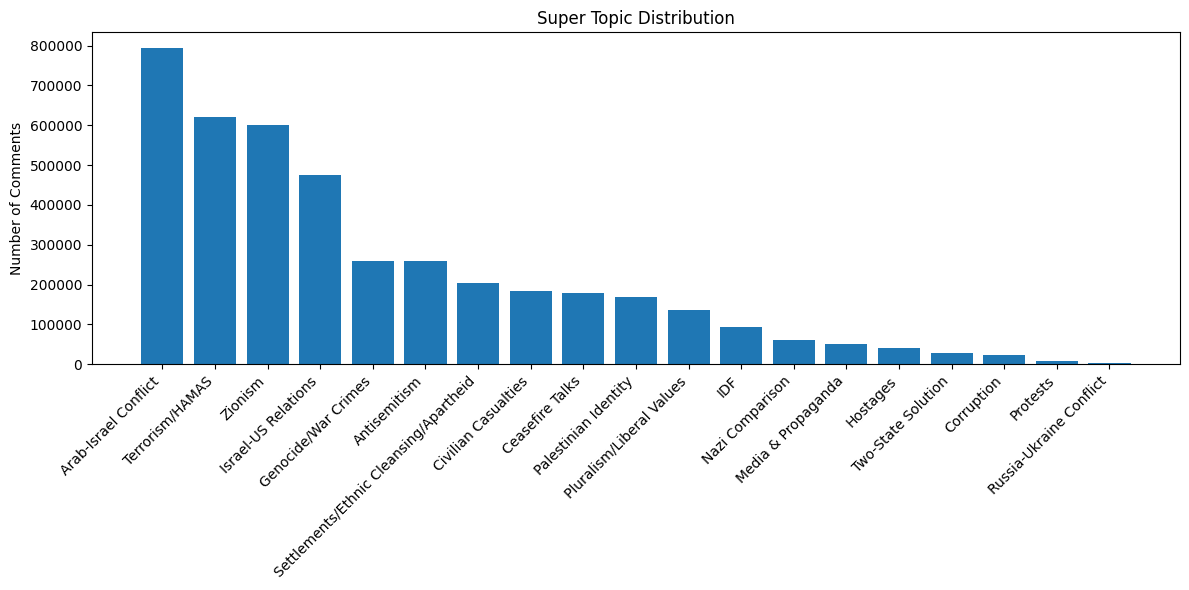

In [ ]:
# Flatten the list of super_topics (filtering out None or NaNs)
all_topics = list(itertools.chain.from_iterable(t for t in tweets_df["super_topics"].dropna() if isinstance(t, list)))
topic_counts = Counter(all_topics)

# Create a sorted DataFrame
topic_freq_df = pd.DataFrame(topic_counts.items(), columns=["Super Topic", "Count"])
topic_freq_df = topic_freq_df.sort_values("Count", ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(topic_freq_df["Super Topic"], topic_freq_df["Count"])
plt.xticks(rotation=45, ha="right")
plt.title("Super Topic Distribution")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()

Post-Process: Tuning the Thresh to get Reasonable Number of SuperTopics per Comment

In [12]:
drive.mount('/content/drive')

# File ID extracted from the URL
OUTPUT_PATH = "/content/drive/MyDrive/classified_comment_stance_with_features.csv"

# Load dataset as pd.DataFrame
tweets_df = pd.read_csv(OUTPUT_PATH)
print("Dataset Size", len(tweets_df))
print("Dataset Columns", tweets_df.columns)
tweets_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Size 847722
Dataset Columns Index(['comment_id', 'self_text', 'created_time', 'author_name', 'ups',
       'downs', 'score', 'post_id', 'subreddit', 'post_self_text',
       'post_title', 'post_created_time', 'post_score', 'user_mentions',
       'media_links', 'predicted_label', 'toxic', 'severe_toxic', 'obscene',
       'threat', 'insult', 'identity_hate', 'sentiment_score', 'factual_score',
       'belief_score', 'emotionality_score', 'super_topics',
       'super_similarities'],
      dtype='object')


,comment_id,self_text,created_time,author_name,ups,downs,score,post_id,subreddit,post_self_text,...,obscene,threat,insult,identity_hate,sentiment_score,factual_score,belief_score,emotionality_score,super_topics,super_similarities
0,mwgten5,We're already there. The killing just isn't en...,2025-06-07 10:08:13,HailLugalKiEn,1,0,1,1l5cxvw,PublicFreakout,NaN,...,0.031515,0.050460,0.020646,0.027010,-0.558051,0.742156,0.000000,0.132246,"['Civilian Casualties', 'Terrorism/HAMAS', 'Ge...",[0.43986845 0.36752692 0.35802308 0.2740437 0...
1,mwgte3r,Thats not the definition of tokenism. That is ...,2025-06-07 10:08:03,Agreeable_Recipe3075,1,0,1,1l53z09,IsraelPalestine,Ive been thinking a lot about what it means to...,...,0.074240,0.045790,0.076220,0.087427,-0.172264,0.156497,0.646623,0.098328,"['Settlements/Ethnic Cleansing/Apartheid', 'An...",[0.4133207 0.37782195 0.35693574 0.3327625 0...
2,mwgtbzy,I dont know if youre being serious but Im goin...,2025-06-07 10:07:29,EastInspection3,1,0,1,1l58igy,IsraelPalestine,I am an AfroCaribbean American who has lived a...,...,0.032075,0.018114,0.041178,0.043722,-0.836618,0.418281,0.321697,0.972248,"['Arab-Israel Conflict', 'Settlements/Ethnic C...",[0.5022005 0.47731826 0.42115223 0.40091413 0...
3,mwgtbo2,"""most""? all i'm hearing from this crowd is the...",2025-06-07 10:07:23,maybe_lucifer,1,0,1,1l5fpuv,worldnews,NaN,...,0.011000,0.029338,0.015336,0.200970,-0.828669,0.375941,0.424184,0.987587,"['Antisemitism', 'Israel-US Relations', 'Plura...",[0.46181196 0.45032856 0.4334771 0.39792 0...
4,mwgtb1r,So what are we doing about Hamas then? I see p...,2025-06-07 10:07:13,Spare_Original_4334,1,0,1,1l5fpuv,worldnews,NaN,...,0.104565,0.082592,0.111765,0.112429,-0.843869,0.551942,0.195922,0.902945,"['Terrorism/HAMAS', 'Arab-Israel Conflict', 'I...",[0.5897095 0.5419529 0.44002032 0.40421504 0...


In [14]:
def parse_similarity_string(s):
    if isinstance(s, float) and pd.isna(s):
        return []
    # Extract all floats using regex
    return [float(x) for x in re.findall(r"\d*\.\d+|\d+", s)]

In [15]:
# Convert stringified lists to actual lists if needed
tweets_df['super_topics'] = tweets_df['super_topics'].fillna('[]').apply(literal_eval)
tweets_df['super_similarities'] = tweets_df['super_similarities'].apply(parse_similarity_string)

def analyze_super_topics(df, threshold=0.2):
    # Filter topics per comment by threshold
    filtered_topics = []
    num_topics_per_comment = []

    for topics, sims in zip(df['super_topics'], df['super_similarities']):
        selected = [topic for topic, sim in zip(topics, sims) if sim >= threshold]
        filtered_topics.append(selected)
        num_topics_per_comment.append(len(selected))

    # Add results to dataframe
    df['selected_topics'] = filtered_topics
    df['num_selected_topics'] = num_topics_per_comment

    # Compute metrics
    avg_topics = sum(num_topics_per_comment) / len(num_topics_per_comment)
    num_no_topics = sum(1 for n in num_topics_per_comment if n == 0)
    topic_counts = Counter(topic for topics in filtered_topics for topic in topics)

    return {
        'average_topics_per_comment': avg_topics,
        'num_comments_with_no_topics': num_no_topics,
        'topic_distribution': dict(topic_counts)
    }

def plot_topic_distribution(topic_distribution):
    topics, counts = zip(*sorted(topic_distribution.items(), key=lambda x: x[1], reverse=True))
    plt.figure(figsize=(12,6))
    plt.bar(topics, counts)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Number of Comments")
    plt.title("Super Topic Distribution (above threshold)")
    plt.tight_layout()
    plt.show()

1.4036795081406404 241900


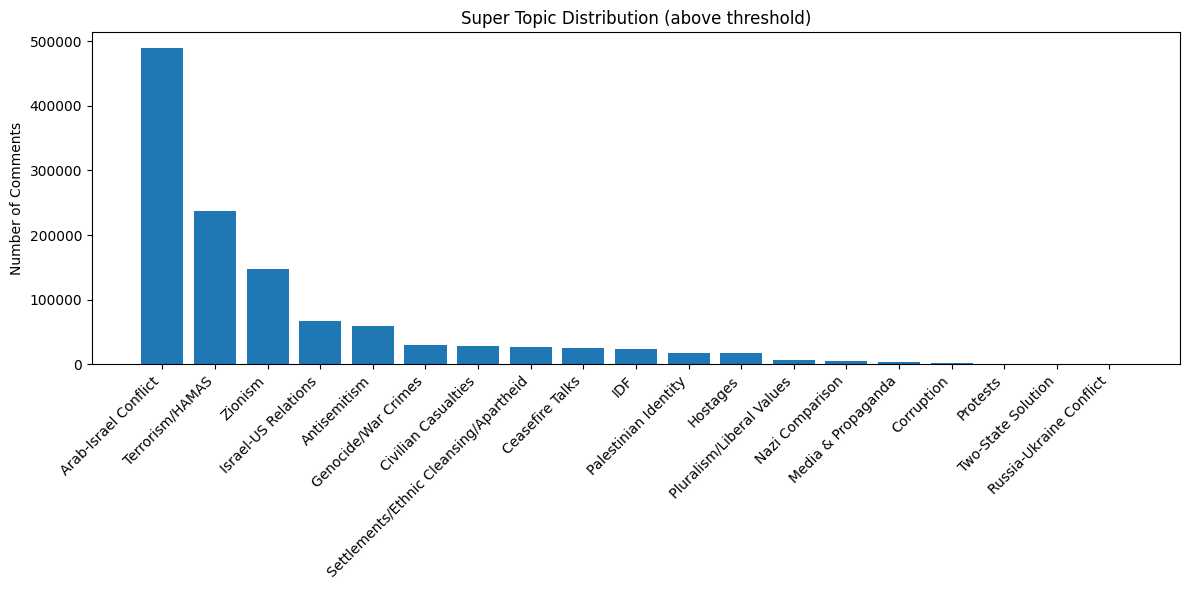

In [33]:
dist = analyze_super_topics(tweets_df, threshold=0.5)
print(dist['average_topics_per_comment'], dist['num_comments_with_no_topics'])
plot_topic_distribution(dist["topic_distribution"])

Saving it Back

In [36]:
tweets_df_filtered = tweets_df[tweets_df['selected_topics'].map(len) > 0].copy()

# Save the DataFrame
tweets_df_filtered.to_csv(OUTPUT_PATH, index=False)

print(len(tweets_df_filtered))
tweets_df_filtered.head()

605822


,comment_id,self_text,created_time,author_name,ups,downs,score,post_id,subreddit,post_self_text,...,insult,identity_hate,sentiment_score,factual_score,belief_score,emotionality_score,super_topics,super_similarities,selected_topics,num_selected_topics
2,mwgtbzy,I dont know if youre being serious but Im goin...,2025-06-07 10:07:29,EastInspection3,1,0,1,1l58igy,IsraelPalestine,I am an AfroCaribbean American who has lived a...,...,0.041178,0.043722,-0.836618,0.418281,0.321697,0.972248,"[Arab-Israel Conflict, Settlements/Ethnic Clea...","[0.5022005, 0.47731826, 0.42115223, 0.40091413...",[Arab-Israel Conflict],1
4,mwgtb1r,So what are we doing about Hamas then? I see p...,2025-06-07 10:07:13,Spare_Original_4334,1,0,1,1l5fpuv,worldnews,NaN,...,0.111765,0.112429,-0.843869,0.551942,0.195922,0.902945,"[Terrorism/HAMAS, Arab-Israel Conflict, Israel...","[0.5897095, 0.5419529, 0.44002032, 0.40421504,...","[Terrorism/HAMAS, Arab-Israel Conflict]",2
5,mwgt66j,You think a terrorist group can mass rape and ...,2025-06-07 10:05:52,Tuskarrr,1,0,1,1l56nfc,IsraelPalestine,I have always been sympathetic to the Palestin...,...,0.013707,0.019517,-0.959720,0.390963,0.360456,0.924219,"[Hostages, Ceasefire Talks, Terrorism/HAMAS, A...","[0.61660856, 0.5403024, 0.46944273, 0.4136727,...","[Hostages, Ceasefire Talks]",2
6,mwgt2h2,It's never going to end. Israel will occupy Ga...,2025-06-07 10:04:50,Ok-Lobster-919,1,0,1,1l5dqzu,IsraelPalestine,"At the begining of this conflict, I said this ...",...,0.040183,0.101031,-0.883477,0.463962,0.267428,0.794804,"[Arab-Israel Conflict, Terrorism/HAMAS, Ceasef...","[0.5020335, 0.44212416, 0.43914098, 0.40026373...",[Arab-Israel Conflict],1
7,mwgsvqy,"... The area was under Israeli control, the 'g...",2025-06-07 10:02:56,TheCounciI,1,0,1,1l5ekk4,worldnews,NaN,...,0.111227,0.134155,-0.563530,0.293213,0.488121,0.290792,"[Arab-Israel Conflict, Settlements/Ethnic Clea...","[0.6072585, 0.4774266, 0.47526804, 0.448698, 0...",[Arab-Israel Conflict],1


# Toxicity Score

In [ ]:
# Load model and tokenizer once
_model_name = "unitary/toxic-bert"
_tokenizer = AutoTokenizer.from_pretrained(_model_name)
_model = AutoModelForSequenceClassification.from_pretrained(_model_name).cuda()
_model.eval()
_label_map = _model.config.id2label  # e.g., {0: 'toxic', ..., 5: 'identity_attack'}

@torch.no_grad()
def extract_toxicity_labels(texts, batch_size=64, max_length=512):
    """
    Fast batched version of toxicity scoring. Truncates long texts to 512 tokens.

    Args:
        texts (List[str]): List of input comments.
        batch_size (int): Batch size for inference.
        max_length (int): Max token length per comment (will truncate longer ones).

    Returns:
        List[Dict[str, float]]: List of dicts with {label: probability} per comment.
    """
    results = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        enc = _tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=max_length)
        enc = {k: v.cuda() for k, v in enc.items()}

        logits = _model(**enc).logits
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()

        for row in probs:
            results.append({_label_map[i]: float(score) for i, score in enumerate(row)})

        # Free GPU memory
        del enc, logits, probs
        torch.cuda.empty_cache()

    return results

tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/811 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [ ]:
texts = tweets_df["self_text"].fillna("").tolist()
toxicity_dicts = extract_toxicity_labels(texts, batch_size=64)
tox_df = pd.DataFrame(toxicity_dicts)
tweets_df = pd.concat([tweets_df.reset_index(drop=True), tox_df], axis=1)

# Save
tweets_df.to_csv(OUTPUT_PATH, index=False)

100%|██████████| 13246/13246 [1:12:15<00:00,  3.06it/s]


# Sentiment Score

In [ ]:
# Load model and tokenizer once
_sentiment_model_name = "cardiffnlp/twitter-roberta-base-sentiment"
_sentiment_tokenizer = AutoTokenizer.from_pretrained(_sentiment_model_name)
_sentiment_model = AutoModelForSequenceClassification.from_pretrained(_sentiment_model_name).cuda()
_sentiment_model.eval()

@torch.no_grad()
def get_sentiment_scores(texts, batch_size=64, max_length=512):
    """
    Fast batched sentiment scorer using truncation.

    Args:
        texts (List[str]): List of input texts.
        batch_size (int): Batch size for GPU inference.
        max_length (int): Max token length (truncates if longer).

    Returns:
        List[float]: Sentiment scores in [-1, 1].
    """
    results = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        enc = _sentiment_tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=max_length)
        enc = {k: v.cuda() for k, v in enc.items()}

        logits = _sentiment_model(**enc).logits
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()

        for row in probs:
            # row = [neg, neutral, pos]
            score = -1 * row[0] + 0 * row[1] + 1 * row[2]
            results.append(float(score))

        # Cleanup
        del enc, logits, probs
        torch.cuda.empty_cache()

    return results

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [ ]:
# Apply sentiment scoring function
texts = tweets_df["self_text"].fillna("").tolist()
sentiment_scores = get_sentiment_scores(texts, batch_size=64)
tweets_df["sentiment_score"] = sentiment_scores

# Save the DataFrame
tweets_df.to_csv(OUTPUT_PATH, index=False)

  0%|          | 0/13246 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

100%|██████████| 13246/13246 [1:10:14<00:00,  3.14it/s]


# Factual Speech vs. Emotional Speech

In [ ]:
# Fact Speaking VS Belief Speaking
fact_speaking_words = [
'actually',
'analyze',
'assess',
'correct',
'correction',
'determine',
'evaluate',
'evidence',
'examine',
'exploration',
'fact',
'information',
'inspect',
'investigate',
'proof',
'prove',
'question',
'quiz',
'real',
'reality',
'rectify',
'research',
'revise',
'sample',
'science',
'scrutinize',
'search',
'specify',
'supervise',
'test',
'trace',
'track',
'trial',
'truth',
'validate',
'verify',
'observe']


belief_speaking_words = [
'basically',
'believe',
'confide',
'consider',
'envisage',
'feel',
'frankly',
'guess',
'obvious',
'obviously',
'of course',
'opinion',
'plainly',
'position',
'presume',
'probably',
'seem',
'sensation',
'sentiment',
'suggestion',
'suppose',
'surely',
'think',
'trust',
'view',
'claim',
'contemplate',
'contention',
'genuinely',
'hint',
'judge',
'look',
'ponder',
'signal',
'suggest',
'try',
'virtually']

# Reuse the same embedder
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Precompute anchor vectors
fact_vec = embedder.encode(fact_speaking_words)
belief_vec = embedder.encode(belief_speaking_words)

fact_vector = np.mean(fact_vec, axis=0)
belief_vector = np.mean(belief_vec, axis=0)

def get_factuality_scores(texts, batch_size=128):
    """
    Batched factuality/emotionality scoring using cosine similarity + subjectivity.

    Args:
        texts (List[str]): List of comments.
        batch_size (int): Batch size for embedding.

    Returns:
        factual_scores (List[float])
        emotional_scores (List[float])
    """
    factual_scores = []
    emotional_scores = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        embeddings = embedder.encode(batch, convert_to_numpy=True)
        subjectivities = [TextBlob(text).sentiment.subjectivity for text in batch]

        fact_sims = cosine_similarity(embeddings, [fact_vector])[:, 0]
        belief_sims = cosine_similarity(embeddings, [belief_vector])[:, 0]

        fact_sims = (fact_sims + 1) / 2  # Normalize to [0, 1]
        belief_sims = (belief_sims + 1) / 2

        for j in range(len(batch)):
            factual_scores.append(fact_sims[j] * (1 - subjectivities[j]))
            emotional_scores.append(belief_sims[j] * subjectivities[j])

    return factual_scores, emotional_scores

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
texts = tweets_df["self_text"].fillna("").tolist()
factuals, emotionals = get_factuality_scores(texts)

tweets_df["factual_score"] = factuals
tweets_df["belief_score"] = emotionals

# Save the DataFrame
tweets_df.to_csv(OUTPUT_PATH, index=False)

# Emotional Level

In [ ]:
# Load once on GPU if available
emotion_model = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    truncation=True,
    device=0  # set to -1 for CPU
)

def get_emotionality_scores(texts, batch_size=32):
    """
    Compute average emotionality score (non-neutral emotion sum) for each comment.

    Args:
        texts (List[str]): List of comment texts.
        batch_size (int): Number of texts to process per batch.

    Returns:
        List[float]: One score per comment, where higher = more emotional.
    """
    emotionality_scores = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]

        try:
            outputs = emotion_model(batch)

            for result in outputs:
                score = sum(r["score"] for r in result if r["label"].lower() != "neutral")
                emotionality_scores.append(score)

        except Exception as e:
            emotionality_scores.extend([None] * len(batch))

    return emotionality_scores

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
texts = tweets_df["self_text"].fillna("").tolist()
emotionalities = get_emotionality_scores(texts, batch_size=32)
tweets_df["emotionality_score"] = emotionalities

# Save the DataFrame
tweets_df.to_csv(OUTPUT_PATH, index=False)

100%|██████████| 26492/26492 [1:16:59<00:00,  5.74it/s]


In [ ]:
import os
os.kill(os.getpid(), 9)